# ZelusBench — Scenario Visualizer

Step through scenario generation point-by-point. Tweak config knobs and see the effect on topology.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Output, HBox, VBox, Label
import ipywidgets as widgets
from IPython.display import display, clear_output

from zelusbench.scenarios.config import ScenarioConfig, QueryType
from zelusbench.scenarios.generator import ScenarioGenerator

In [15]:
# ============================================================
# TWEAK THESE — regenerate trace by re-running this cell + next
# ============================================================
cfg = ScenarioConfig(
    dim=2,                # 2 or 3
    # min_chain_depth=6,
    # max_chain_depth=8,
    leaf_bias=0.5,        # 0.0=bushy, 1.0=linear
    num_points=12,        # total points (chain + distractors)
    transform_prob=0.0,   # probability of transform per step
    query_types=[QueryType.POSITION, QueryType.DISTANCE, QueryType.BOOLEAN],
    num_queries=3,
    seed=42,
)

gen = ScenarioGenerator(cfg)
trace = gen.generate_trace("viz")
print(f"Generated {len(trace)} steps: "
      f"{sum(1 for t in trace if t['type']=='point')} points, "
      f"{sum(1 for t in trace if t['type']=='transform')} transforms, "
      f"{sum(1 for t in trace if t['type']=='query')} queries")

Generated 15 steps: 12 points, 0 transforms, 3 queries


In [ ]:
# ============================================================
# Interactive step-through visualizer
# ============================================================

# Color map: phase 1 = blue, phase 2 = green, transforms = orange
PHASE_COLORS = {1: "#3b82f6", 2: "#22c55e"}
TRANSFORM_COLOR = "#f97316"
QUERY_COLOR = "#a855f7"
ORIGIN_COLOR = "#6b7280"
LEAF_COLOR = "#ef4444"


def draw_step(step_idx):
    """Draw the space at a given step."""
    s = trace[step_idx]
    snap = s["space"]
    positions = snap["positions"]
    edges = snap["edges"]
    depths = snap["depths"]
    leaves = set(snap["leaves"])
    dim = cfg.dim

    fig = plt.figure(figsize=(14, 6))

    # --- Left: spatial plot ---
    if dim == 3:
        ax = fig.add_subplot(121, projection="3d")
    else:
        ax = fig.add_subplot(121)

    # Draw edges
    for a, b in edges:
        pa, pb = np.array(positions[a]), np.array(positions[b])
        if dim == 3:
            ax.plot([pa[0], pb[0]], [pa[1], pb[1]], [pa[2], pb[2]],
                    color="#d1d5db", linewidth=1, zorder=1)
        else:
            ax.plot([pa[0], pb[0]], [pa[1], pb[1]],
                    color="#d1d5db", linewidth=1, zorder=1)

    # Collect points added up to this step (determine which step added each)
    point_step = {}  # point_name -> step_index
    for i, t in enumerate(trace[:step_idx + 1]):
        if t["type"] == "point":
            point_step[t["extras"]["name"]] = i

    # Draw points
    for name, pos in positions.items():
        p = np.array(pos)
        if name == "O":
            color = ORIGIN_COLOR
            marker = "s"
            size = 80
        elif name == s["extras"].get("name"):  # current step's point
            color = "#dc2626" if s["type"] == "point" else PHASE_COLORS.get(s["phase"], "gray")
            marker = "*"
            size = 200
        elif name in leaves:
            color = LEAF_COLOR
            marker = "o"
            size = 60
        else:
            ps = point_step.get(name, 0)
            phase = trace[ps]["phase"] if ps < len(trace) else 1
            color = PHASE_COLORS.get(phase, "gray")
            marker = "o"
            size = 50

        if dim == 3:
            ax.scatter(p[0], p[1], p[2], c=color, s=size, marker=marker,
                       edgecolors="black", linewidth=0.5, zorder=5)
            ax.text(p[0], p[1], p[2] + 0.3, name, fontsize=8, ha="center", zorder=6)
        else:
            ax.scatter(p[0], p[1], c=color, s=size, marker=marker,
                       edgecolors="black", linewidth=0.5, zorder=5)
            ax.text(p[0], p[1] + 0.3, name, fontsize=8, ha="center", zorder=6)

    ax.set_title(f"Space ({dim}D) — Step {step_idx}/{len(trace)-1}", fontsize=11)
    if dim == 2:
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

    # --- Right: info panel ---
    ax2 = fig.add_subplot(122)
    ax2.axis("off")

    info_lines = []
    step_type = s["type"].upper()
    phase = s["phase"]
    extras = s["extras"]

    info_lines.append(f"Step {step_idx}  |  Phase {phase}  |  {step_type}")
    info_lines.append("─" * 40)
    info_lines.append(s["text"])
    info_lines.append("")

    if s["type"] == "point":
        info_lines.append(f"Point:   {extras['name']}")
        info_lines.append(f"Type:    {extras['def_type']}")
        info_lines.append(f"Anchors: {extras['anchors']}")
        info_lines.append(f"Depth:   {extras['depth']}")
        if "must_extend" in extras:
            info_lines.append(f"Forced:  {extras['must_extend']}")
        if "effective_lb" in extras:
            info_lines.append(f"Eff. LB: {extras['effective_lb']}")
    elif s["type"] == "transform":
        info_lines.append(f"Transform: {extras['transform_type']}")
        info_lines.append(f"Affected:  {extras['affected_points']}")
    elif s["type"] == "query":
        info_lines.append(f"Query:   {extras['query_id']}")
        info_lines.append(f"Type:    {extras['query_type']}")
        info_lines.append(f"Targets: {extras['targets']}")
        info_lines.append(f"Depth:   {extras['depth']}")

    info_lines.append("")
    info_lines.append(f"Points: {len(positions)-1}  |  Leaves: {len(leaves)}")
    info_lines.append(f"Max depth: {max(depths.values()) if depths else 0}")

    # Depth histogram
    if depths:
        depth_counts = {}
        for d in depths.values():
            depth_counts[d] = depth_counts.get(d, 0) + 1
        hist_str = "  ".join(f"d{d}:{c}" for d, c in sorted(depth_counts.items()))
        info_lines.append(f"Depth dist: {hist_str}")

    ax2.text(0.05, 0.95, "\n".join(info_lines), transform=ax2.transAxes,
             fontsize=9, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f8fafc", edgecolor="#e2e8f0"))

    plt.tight_layout()
    plt.show()


step_slider = IntSlider(min=0, max=len(trace)-1, step=1, value=0,
                        description="Step:", continuous_update=False,
                        layout=widgets.Layout(width="80%"))
interact(draw_step, step_idx=step_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', layout=Layout(width='80…

<function __main__.draw_step(step_idx)>

In [10]:
# ============================================================
# Full text log with step types color-coded
# ============================================================
for t in trace:
    phase_tag = f"P{t['phase']}"
    extras = t["extras"]
    if t["type"] == "point":
        depth = extras["depth"]
        forced = " [FORCED]" if extras.get("must_extend") else ""
        print(f"  [{phase_tag}] {t['text']:60s}  depth={depth}{forced}")
    elif t["type"] == "transform":
        print(f"  [{phase_tag}] >>> {t['text']}")
    elif t["type"] == "query":
        print(f"  [{phase_tag}] ??? {t['text']}  targets={extras['targets']}")

  [P1] Point A is at offset (-3.2, -1.5, -1.8) from Point O.         depth=1
  [P1] Point B is at offset (-4.7, -4.1, -2.7) from Point A.         depth=2
  [P1] Point C is the weighted centroid of Point B (weight 0.8), Point A (weight 0.1).  depth=3
  [P2] Point D is the midpoint of Point A and Point C and Point B.   depth=4
  [P2] Point E is at offset (-0.9, -1.0, -1.6) from Point D.         depth=5
  [P2] Point F is at offset (3.2, -0.8, 0.3) from Point E.           depth=6
  [P2] ??? [Query q_000] Position of D? (x, y, z)  targets=['D']
  [P2] Point G is at offset (1.1, 1.8, 3.2) from Point F.            depth=7
  [P2] Point H is at offset (-0.8, -0.3, 2.2) from Point G.          depth=8
  [P2] Point I is 5.4 units from Point H in the direction (-0.8, -1.4, -0.2).  depth=9
  [P2] ??? [Query q_001] Is H closer to G or C?  targets=['H', 'G', 'C']
  [P2] Point J is 6.4 units from Point I in the direction (-0.3, -0.8, -1.8).  depth=10
  [P2] Point K is the midpoint of Point E and Point 

In [11]:
# ============================================================
# Final topology: dependency tree
# ============================================================
final = trace[-1]["space"]

def print_tree(node, edges, depth=0, visited=None):
    if visited is None:
        visited = set()
    if node in visited:
        return
    visited.add(node)
    d = final["depths"].get(node, 0)
    pos = final["positions"][node]
    pos_str = f"({', '.join(f'{x:.1f}' for x in pos)})"
    leaf = " *" if node in set(final["leaves"]) else ""
    print(f"{'  ' * depth}{node} [d={d}] {pos_str}{leaf}")
    children = [b for a, b in edges if a == node]
    for c in children:
        print_tree(c, edges, depth + 1, visited)

print("Dependency tree (leaves marked with *):\n")
print_tree("O", final["edges"])

Dependency tree (leaves marked with *):

O [d=0] (0.0, 0.0, 0.0)
  A [d=1] (-3.2, -1.5, -1.8)
    B [d=2] (-7.9, -5.6, -4.5)
      C [d=3] (-7.4, -5.1, -4.2)
        D [d=4] (-6.2, -4.1, -3.5)
          E [d=5] (-7.1, -5.1, -5.1)
            F [d=6] (-3.9, -5.9, -4.8)
              G [d=7] (-2.8, -4.1, -1.6)
                H [d=8] (-3.6, -4.4, 0.6)
                  I [d=9] (-6.1, -9.1, 0.1)
                    J [d=10] (-7.3, -11.6, -5.7) *
                  L [d=9] (-5.3, -4.6, -1.9) *
            K [d=6] (-7.0, -4.9, -4.4)


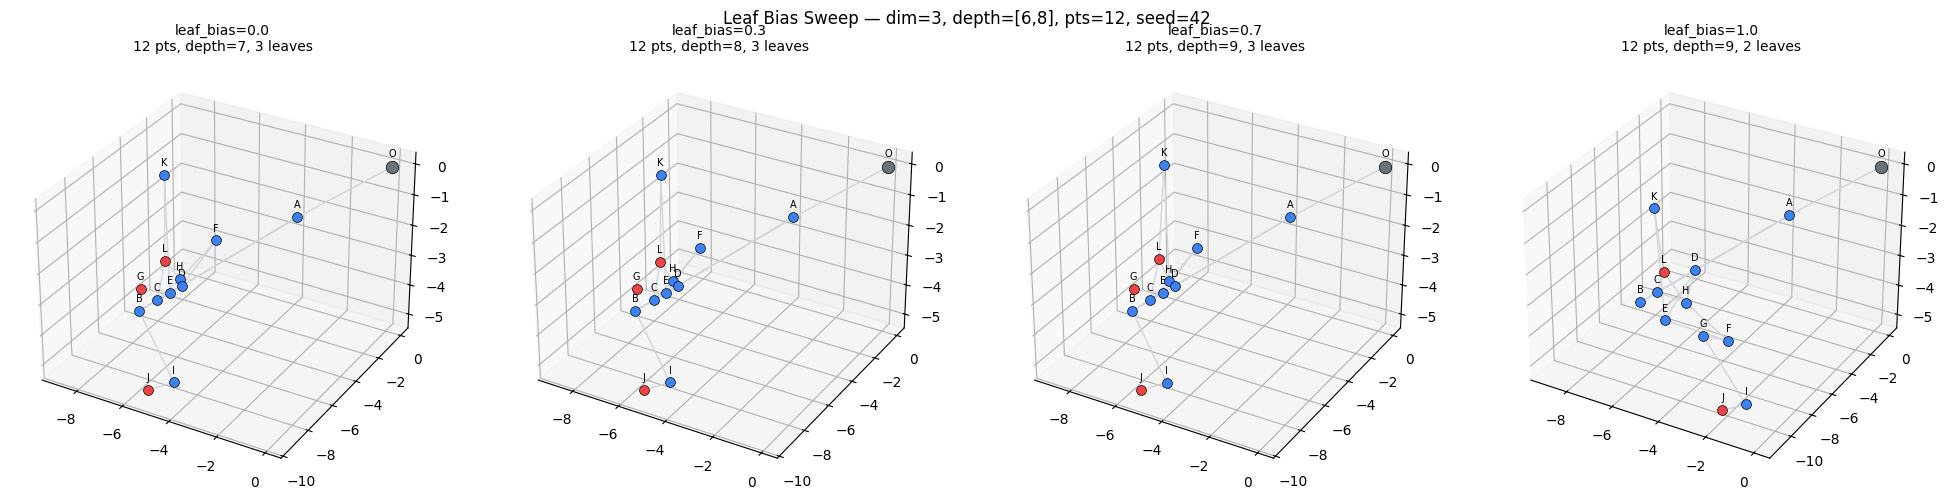

In [ ]:
# ============================================================
# Quick comparison: sweep leaf_bias
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5),
                         subplot_kw={"projection": "3d"} if cfg.dim == 3 else {})

for ax, nps in zip(axes, [4, 8, 16]):
    c = ScenarioConfig(
        dim=cfg.dim, num_points=nps,
        transform_prob=0.0, num_queries=0, seed=cfg.seed,
    )
    g = ScenarioGenerator(c)
    t = g.generate_trace("cmp")
    final_snap = t[-1]["space"]
    positions = final_snap["positions"]
    edges = final_snap["edges"]
    leaves = set(final_snap["leaves"])
    depths = final_snap["depths"]

    for a, b in edges:
        pa, pb = np.array(positions[a]), np.array(positions[b])
        if cfg.dim == 3:
            ax.plot([pa[0], pb[0]], [pa[1], pb[1]], [pa[2], pb[2]],
                    color="#d1d5db", linewidth=1)
        else:
            ax.plot([pa[0], pb[0]], [pa[1], pb[1]], color="#d1d5db", linewidth=1)

    for name, pos in positions.items():
        p = np.array(pos)
        color = ORIGIN_COLOR if name == "O" else (LEAF_COLOR if name in leaves else "#3b82f6")
        size = 80 if name == "O" else 50
        if cfg.dim == 3:
            ax.scatter(p[0], p[1], p[2], c=color, s=size,
                       edgecolors="black", linewidth=0.5)
            ax.text(p[0], p[1], p[2] + 0.3, name, fontsize=7, ha="center")
        else:
            ax.scatter(p[0], p[1], c=color, s=size,
                       edgecolors="black", linewidth=0.5)
            ax.text(p[0], p[1] + 0.3, name, fontsize=7, ha="center")

    max_d = max(depths.values()) if depths else 0
    ax.set_title(f"leaf_bias={lb}\n{len(positions)-1} pts, depth={max_d}, {len(leaves)} leaves",
                 fontsize=10)
    if cfg.dim == 2:
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

plt.suptitle(f"Leaf Bias Sweep — dim={cfg.dim}, depth=[{cfg.min_chain_depth},{cfg.max_chain_depth}], "
             f"pts={cfg.num_points}, seed={cfg.seed}", fontsize=12)
plt.tight_layout()
plt.show()